<img src=".\assets\on_black.png" alt="netective logo" style="width:18%;">

Compare networks based on their structure and performance statistics.
<br><br>
## Python Module Tutorial

Explore the main features of the Python module for network comparison.

- For a tutorial on the command-line interface, refer to [this link]().
- Access the web service for small jobs [here]().

---

The module consists of two submodules: `structure` and `stats`, each with module-level functions for convenient usage.

In this guide, we'll cover the following topics:

1. **Module-level functions** 📦
2. **Submodule `structure`** 🕸️📐
   Useful for comparing networks with different node IDs.

3. **Submodule `stats`** 📊
   Requires networks to share node IDs. Useful for comparing inferred networks against a gold standard.

<br>

Make sure to have netective installed:

In [1]:
# %pip install netective

<br>

### Module-level functions 📦

The module-level functions empower users, even those with basic Python proficiency, to seamlessly employ netective to characterize network structure, compare networks, and assess inference performance.

In [1]:
# Third-party imports
import networkx as nx
from scipy.stats import spearmanr

#### characterize network structure

C:\Users\jmere\Dropbox (FreyreLab)\netective\src\netective\utils.py:259: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = skew(data, nan_policy="omit")
C:\Users\jmere\Dropbox (FreyreLab)\netective\src\netective\utils.py:260: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(data, nan_policy="omit")


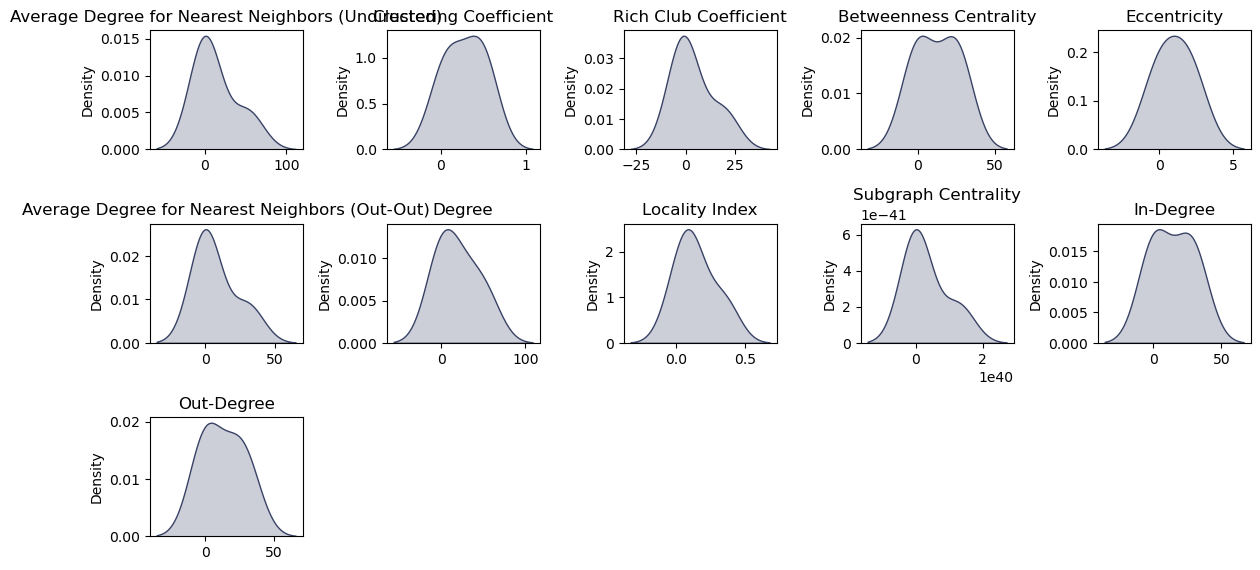

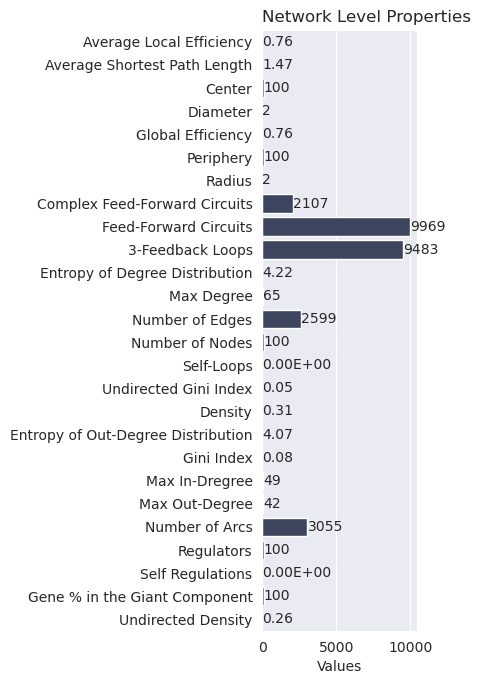

In [2]:
from netective import characterize_network

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)

# Characterize the network is as simple as calling the function with the network and an identifier as arguments
characterize_network(G, "my_network")

Networks may have different size. Use the norm parameter to get normalized values.

C:\Users\jmere\Dropbox (FreyreLab)\netective\src\netective\utils.py:259: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = skew(data, nan_policy="omit")
C:\Users\jmere\Dropbox (FreyreLab)\netective\src\netective\utils.py:260: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(data, nan_policy="omit")


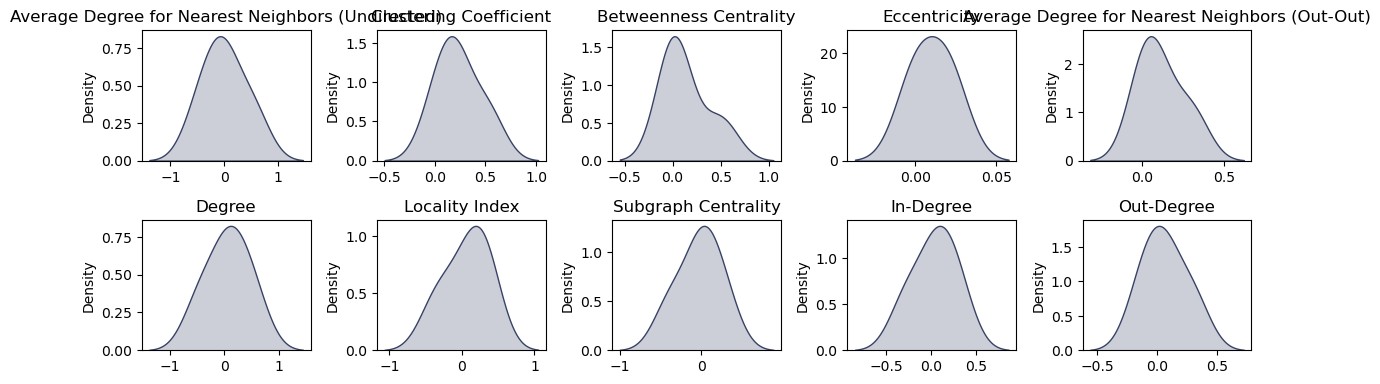

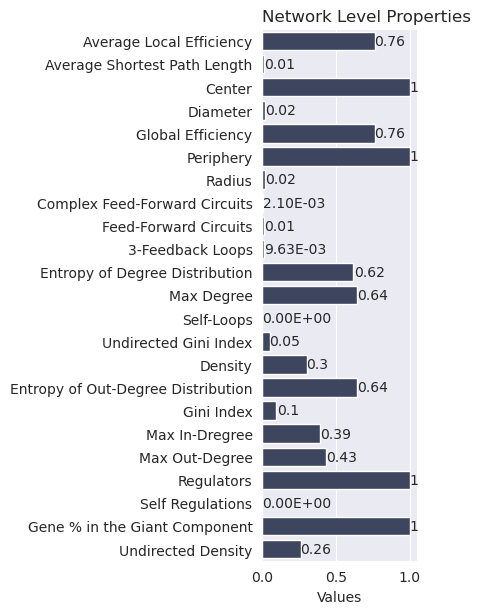

In [4]:
# norm parameter allows you to normalize data using different approaches depending on the nature of the networks analyzed
# default is None for no normalization, uses raw data
# norm = "network" normalize the network by the network size

characterize_network(G, "my_network", norm="network")

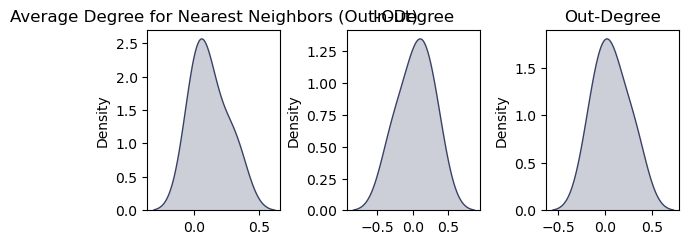

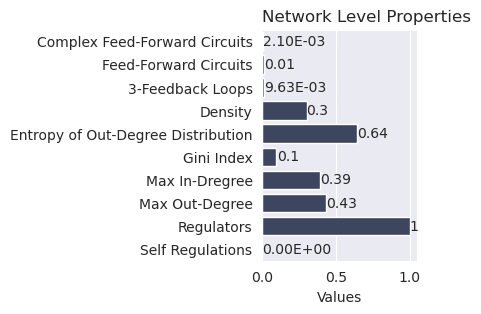

In [5]:
# norm = "biological" normalize the network by the number of regulators

characterize_network(G, "my_network", norm="biological")

Netective v1.0 uses a total of 28 network properties for characterization and comparison:

`Node-Level Properties`
- In-Degree (InDegre)
- Out-Degree (OutDegre)
- Locality Index (LocalityIndex)
- Subgraph Centrality (SubgraphCentrality)
- Average Degree of Nearest Neighbors using out-out degree (AverageOutDegreeNearestNeighbors)
- Average Degree of Nearest Neighbors using undirected network (AverageDegreeNearestNeighbors)
- Clustering Coefficient (ClusteringCoefficient)
- Rich Club Coefficient (RichClub)
- Betweenness Centrality (BetweennessCentrality)
- Eccentricity (Eccentricity)

`Network-Level Properties`
- Entropy of Degree Distribution (EntropyPKout)
- Gini Index (GiniIndex)
- Max In-Degree (MaxInDegree)
- Max Out-Degree (MaxOutDegree)
- Regulators (Regulators)
- Self-Regulations (SelfRegulations)
- Density (Density)
- Complex Feed-Forward Circuits (ComplexFeedForwardCircuits)
- 3-Feedback Loops (FeedbakcLoops_3)
- Average Clustering Coefficient (AverageClusteringCoefficient)
- Gene % in the Giant Component (GenesintheGiantComponent)
- Average Local Efficiency (AverageLocalEfficiency)
- Average Shortest Path Length (AverageShortestPathLength)
- Center (Center)
- Diameter (Diameter)
- Global Efficiency (GlobalEfficiency)
- Periphery (Periphery)
- Radius (Radius)

***correct spelling for list in parenthesis***

characterize_network function allows you to provide a list of chosen properties to use if you do not want to use the complete set, using the parameter selected_props ***default is all properties***

Density
Diameter
Gini Index




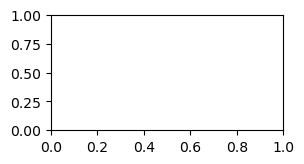

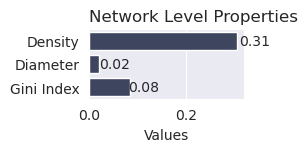

In [4]:
# using the same network

my_properties = ['Gini Index', 'Density', 'Diameter', 'LocalityIndex', 'InDegree', 'RichClub']

characterize_network(G, "my_network", norm="network", selected_props= my_properties)

#### compare networks based on their structure



100%|██████████| 2/2 [00:03<00:00,  1.86s/it]


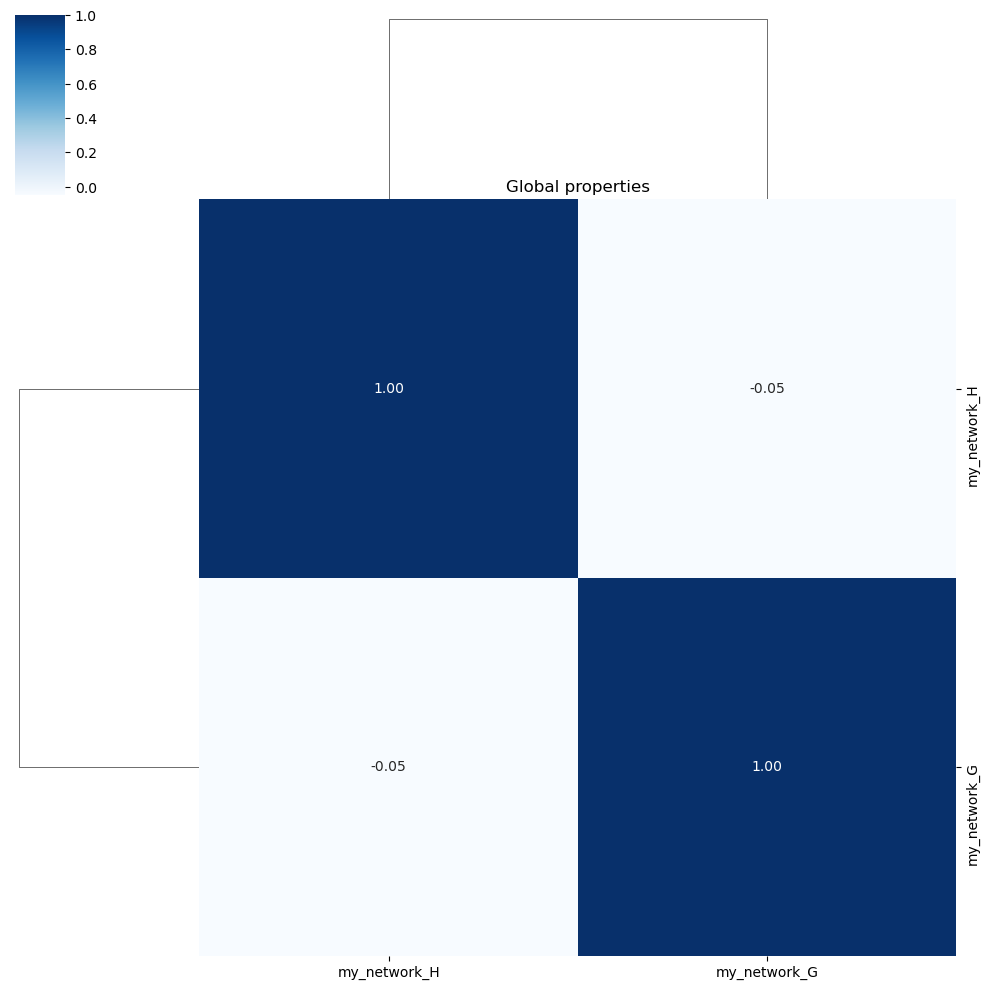

In [17]:
from netective import compare_structure
import networkx as nx

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks, return_prop_dicts=False);



100%|██████████| 2/2 [00:02<00:00,  1.31s/it]


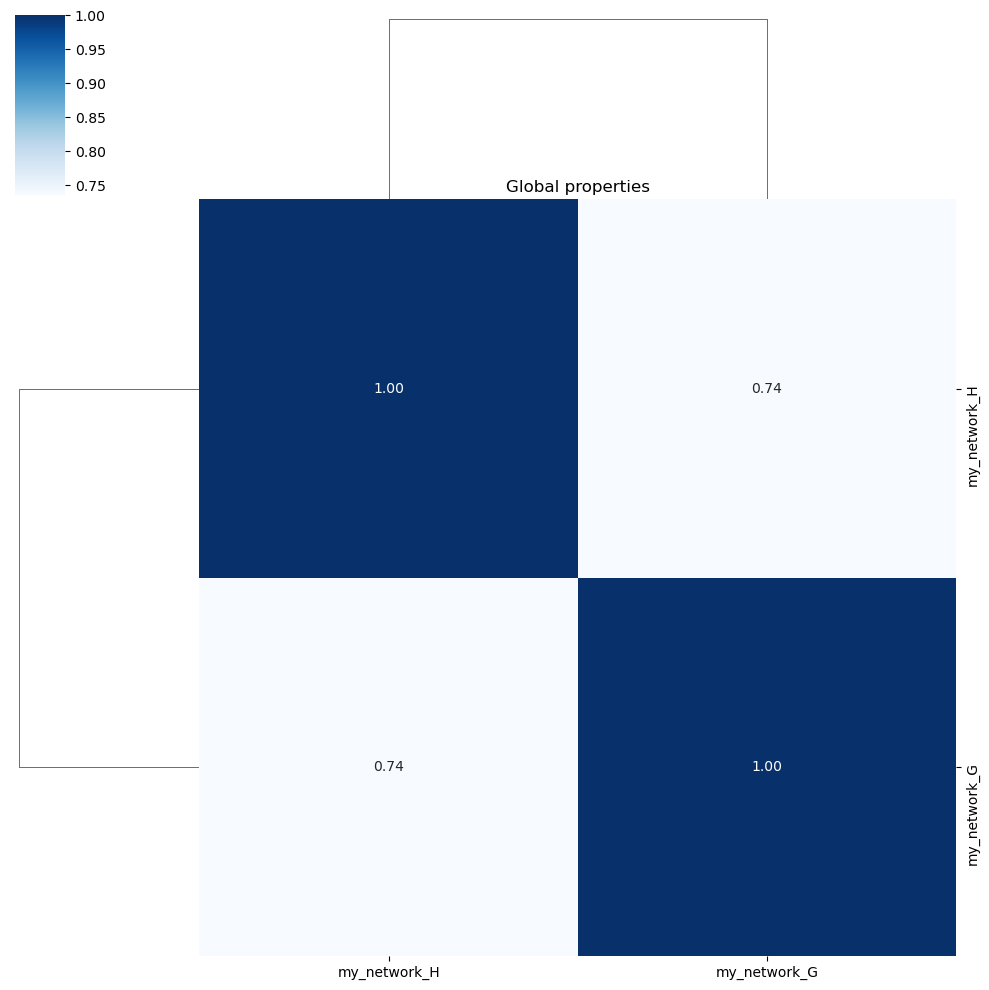

In [16]:
# pearsonr is used by default to compare networks. Other methods are available using the parameter association_metric.
# compare_structure runs in parallel by default. Use workers to specify the number of processes to run in parallel.
# TODO definir bien cómo es la comparación de redes

compare_structure(networks, workers=2, association_metric=spearmanr);

Density
Regulators


100%|██████████| 2/2 [00:01<00:00,  1.03it/s]


c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\seaborn\matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)
c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\seaborn\matrix.py:623: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_dependent_coord * 1.05)


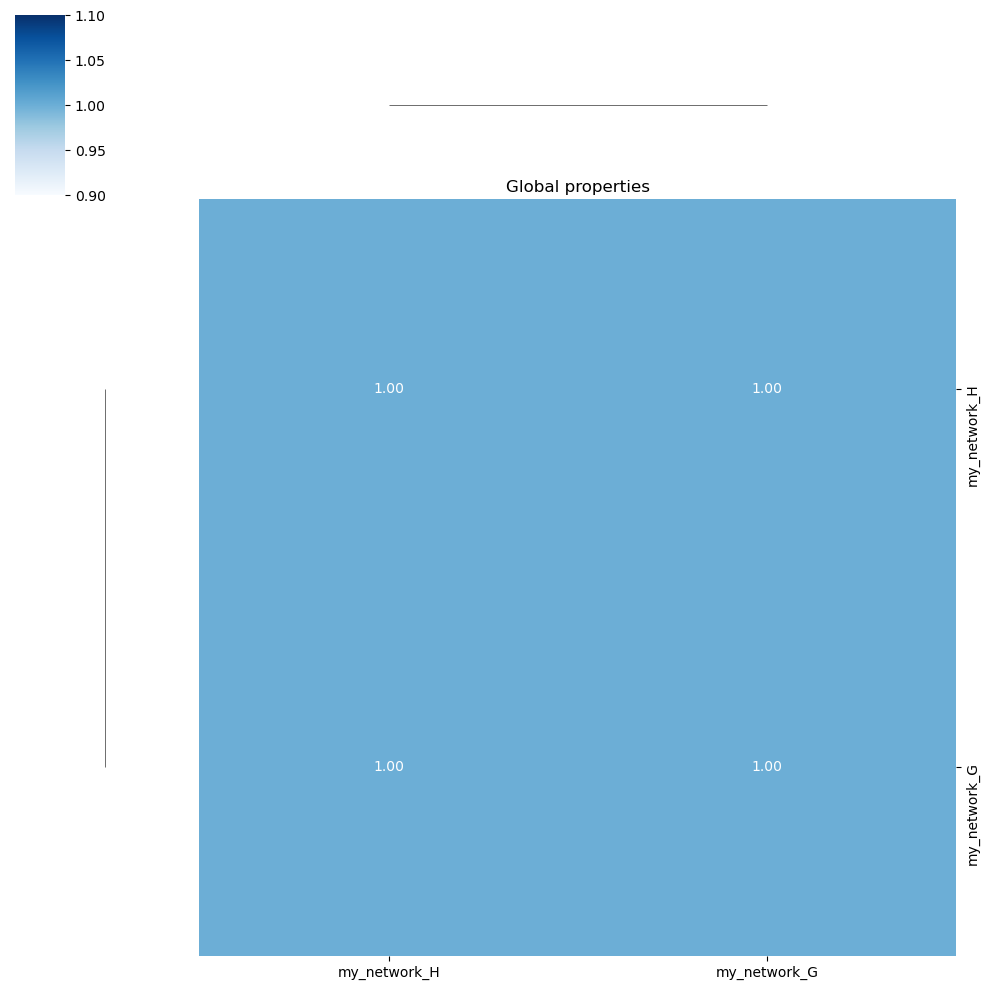

In [18]:
# just like characterize_network, compare_structure function allows you to provide the list of chosen properties for analysis using the parameter selected_props

my_properties = ['EntropyPKout', 'ClusteringCoefficient', 'OutDegree', 'Density', 'Regulators']
compare_structure(networks, workers=2, association_metric=spearmanr, selected_props= my_properties);



100%|██████████| 20/20 [00:04<00:00,  4.57it/s]


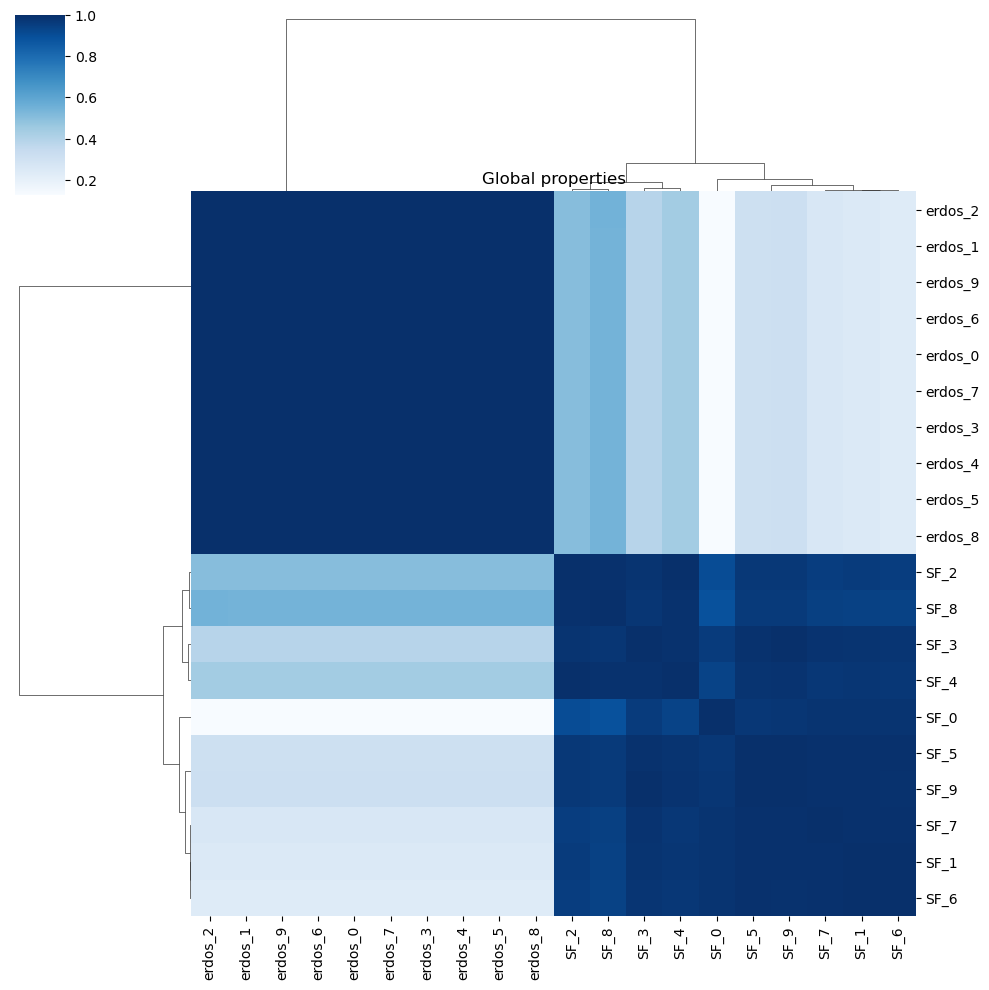

In [20]:
# Lets create a dict with 10 random networks to see the power of compare_structure

erdos_nets = {f'erdos_{i}': nx.fast_gnp_random_graph(100, 0.1, directed=True) for i in range(10)}
sf_nets = {f'SF_{i}': nx.DiGraph(nx.scale_free_graph(100)) for i in range(10)}

name_nets = {**erdos_nets, **sf_nets}

compare_structure(name_nets);



100%|██████████| 2/2 [00:02<00:00,  1.28s/it]


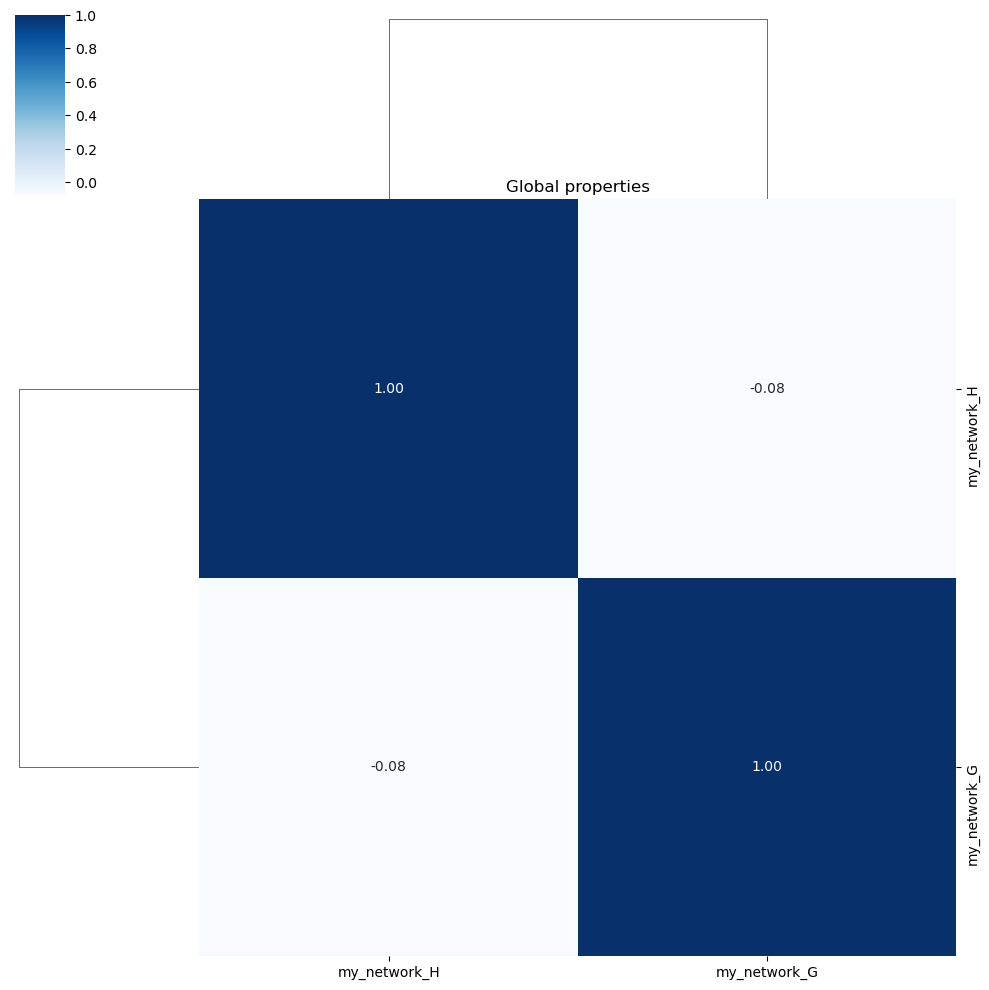

In [14]:
# Netective is also capable to compare a directed network with an undirected one
# A subset of properties they share is selected for analysis
# Biological normalization not recommended for this type of comparison

# Let's create a random UNDIRECTED network.
G = nx.erdos_renyi_graph(100, 0.3, directed=False)
# Let's create a second network to compare to the first one. Notice this is a directed network
H = nx.path_graph(50, create_using=nx.DiGraph)

networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks, norm='network', workers='auto');

<br>

### **Submodule `structure`** 🕸️📐

In [12]:
from netective.structure.structure import Structure

In [13]:
# The object Structure allows you to observe a graph constantly.

G = nx.erdos_renyi_graph(100, 0.2, directed=True)
s = Structure(G)
s.get_props()

Properties used for analysis: 
Average Degree for Nearest Neighbors (Undirected)
Average Local Efficiency
Average Degree for Nearest Neighbors (Out-Out)
Average Shortest Path Length
Betweenness Centrality
Center
Clustering Coefficient
Complex Feed-Forward Circuits
Degree
Density
Diameter
Eccentricity
Entropy of Degree Distribution
Entropy of Out-Degree Distribution
Feed-Forward Circuits
3-Feedback Loops
Gene % in the Giant Component
Gini Index
Global Efficiency
In-Degree
Locality Index
Max Degree
Max In-Dregree
Max Out-Degree
Number of Arcs
Number of Edges
Number of Nodes
Out-Degree
Periphery
Radius
Regulators
Rich Club Coefficient
Self-Loops
Self Regulations
Subgraph Centrality
Undirected Density
Undirected Gini Index




C:\Users\jmere\Dropbox (FreyreLab)\netective\src\netective\utils.py:259: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = skew(data, nan_policy="omit")
C:\Users\jmere\Dropbox (FreyreLab)\netective\src\netective\utils.py:260: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(data, nan_policy="omit")


({'d7a37f11-d178-47fa-9de4-6823243da439': {'Average Local Efficiency': 0.6819031235445017,
   'Average Shortest Path Length': 1.638989898989899,
   'Center': 100,
   'Diameter': 2,
   'Global Efficiency': 0.6805050505050505,
   'Periphery': 100,
   'Radius': 2,
   'Complex Feed-Forward Circuits': 471,
   'Feed-Forward Circuits': 4190,
   '3-Feedback Loops': 2602,
   'Entropy of Degree Distribution': 4.044772064274538,
   'Max Degree': 53,
   'Number of Edges': 1787,
   'Number of Nodes': 100,
   'Self-Loops': 0,
   'Undirected Gini Index': 0.07764969222160023,
   'Density': 0.1975,
   'Entropy of Out-Degree Distribution': 3.9493743376069537,
   'Gini Index': 0.11920506329113956,
   'Max In-Dregree': 31,
   'Max Out-Degree': 32,
   'Number of Arcs': 1975,
   'Regulators': 100,
   'Self Regulations': 0,
   'Gene % in the Giant Component': 100,
   'Undirected Density': 0.1787}},
 {'d7a37f11-d178-47fa-9de4-6823243da439': {'Average Degree for Nearest Neighbors (Undirected)': (36.48525468088

In [14]:
# if the graphs has not changed, it returned the curret props dict
s.get_props()

({'d7a37f11-d178-47fa-9de4-6823243da439': {'Average Local Efficiency': 0.6819031235445017,
   'Average Shortest Path Length': 1.638989898989899,
   'Center': 100,
   'Diameter': 2,
   'Global Efficiency': 0.6805050505050505,
   'Periphery': 100,
   'Radius': 2,
   'Complex Feed-Forward Circuits': 471,
   'Feed-Forward Circuits': 4190,
   '3-Feedback Loops': 2602,
   'Entropy of Degree Distribution': 4.044772064274538,
   'Max Degree': 53,
   'Number of Edges': 1787,
   'Number of Nodes': 100,
   'Self-Loops': 0,
   'Undirected Gini Index': 0.07764969222160023,
   'Density': 0.1975,
   'Entropy of Out-Degree Distribution': 3.9493743376069537,
   'Gini Index': 0.11920506329113956,
   'Max In-Dregree': 31,
   'Max Out-Degree': 32,
   'Number of Arcs': 1975,
   'Regulators': 100,
   'Self Regulations': 0,
   'Gene % in the Giant Component': 100,
   'Undirected Density': 0.1787}},
 {'d7a37f11-d178-47fa-9de4-6823243da439': {'Average Degree for Nearest Neighbors (Undirected)': (36.48525468088

In [15]:
# but recalculates the props if the graph changes without creating a new instance of the class.
G.add_edge("A", "B")
s.get_props()

Properties used for analysis: 
Average Degree for Nearest Neighbors (Undirected)
Average Local Efficiency
Average Degree for Nearest Neighbors (Out-Out)
Average Shortest Path Length
Betweenness Centrality
Center
Clustering Coefficient
Complex Feed-Forward Circuits
Degree
Density
Diameter
Eccentricity
Entropy of Degree Distribution
Entropy of Out-Degree Distribution
Feed-Forward Circuits
3-Feedback Loops
Gene % in the Giant Component
Gini Index
Global Efficiency
In-Degree
Locality Index
Max Degree
Max In-Dregree
Max Out-Degree
Number of Arcs
Number of Edges
Number of Nodes
Out-Degree
Periphery
Radius
Regulators
Rich Club Coefficient
Self-Loops
Self Regulations
Subgraph Centrality
Undirected Density
Undirected Gini Index




({'d7a37f11-d178-47fa-9de4-6823243da439': {'Average Local Efficiency': 0.6819031235445017,
   'Average Shortest Path Length': 1.638989898989899,
   'Center': 100,
   'Diameter': 2,
   'Global Efficiency': 0.6805050505050505,
   'Periphery': 100,
   'Radius': 2,
   'Complex Feed-Forward Circuits': 471,
   'Feed-Forward Circuits': 4190,
   '3-Feedback Loops': 2602,
   'Entropy of Degree Distribution': 4.104695807167391,
   'Max Degree': 53,
   'Number of Edges': 1788,
   'Number of Nodes': 102,
   'Self-Loops': 0,
   'Undirected Gini Index': 0.09513313155239744,
   'Density': 0.1975,
   'Entropy of Out-Degree Distribution': 4.030776467297211,
   'Gini Index': 0.13591529729300678,
   'Max In-Dregree': 31,
   'Max Out-Degree': 32,
   'Number of Arcs': 1976,
   'Regulators': 101,
   'Self Regulations': 0,
   'Gene % in the Giant Component': 100,
   'Undirected Density': 0.1787}},
 {'d7a37f11-d178-47fa-9de4-6823243da439': {'Average Degree for Nearest Neighbors (Undirected)': (35.789465373420

In [16]:
s.norm = "network"
s.get_props()

Properties used for analysis: 
Average Degree for Nearest Neighbors (Undirected)
Average Local Efficiency
Average Degree for Nearest Neighbors (Out-Out)
Average Shortest Path Length
Betweenness Centrality
Center
Clustering Coefficient
Complex Feed-Forward Circuits
Degree
Density
Diameter
Eccentricity
Entropy of Degree Distribution
Entropy of Out-Degree Distribution
Feed-Forward Circuits
3-Feedback Loops
Gene % in the Giant Component
Gini Index
Global Efficiency
In-Degree
Locality Index
Max Degree
Max In-Dregree
Max Out-Degree
Number of Arcs
Number of Edges
Number of Nodes
Out-Degree
Periphery
Radius
Regulators
Rich Club Coefficient
Self-Loops
Self Regulations
Subgraph Centrality
Undirected Density
Undirected Gini Index


Properties excluded from analysis due to lack of normalization:
Rich Club Coefficient
Number of Edges
Number of Nodes
Number of Arcs


({'d7a37f11-d178-47fa-9de4-6823243da439': {'Average Local Efficiency': 0.6819031235445017,
   'Average Shortest Path Length': 0.016555453525150494,
   'Center': 1.0,
   'Diameter': 0.020202020202020204,
   'Global Efficiency': 0.6805050505050505,
   'Periphery': 1.0,
   'Radius': 0.020202020202020204,
   'Complex Feed-Forward Circuits': 0.00045719277810133953,
   'Feed-Forward Circuits': 0.004067171423024656,
   '3-Feedback Loops': 0.0025257231605513492,
   'Entropy of Degree Distribution': 0.6151729838545605,
   'Max Degree': 0.5196078431372549,
   'Self-Loops': 0.0,
   'Undirected Gini Index': 0.09513313155239744,
   'Density': 0.1975,
   'Entropy of Out-Degree Distribution': 0.6040946523511407,
   'Gini Index': 0.13591529729300678,
   'Max In-Dregree': 0.30392156862745096,
   'Max Out-Degree': 0.3137254901960784,
   'Regulators': 0.9901960784313726,
   'Self Regulations': 0.0,
   'Gene % in the Giant Component': 1.0,
   'Undirected Density': 0.1787}},
 {'d7a37f11-d178-47fa-9de4-6823

### **Submodule `stats`** 🕸️📐

This module allows you to evaluate an inferred network against a gold standard.

In [1]:
# import the module
from netective.stats import stats

In [2]:
from netective.utils import parse_network
pred = 'assets\\short_100226_v2019_sFL_dAllInc_BSs.pred'
gs = 'assets\\short_GS.txt'


pred_graph = parse_network(pred, delimiter='\t', directed=True, score=True, use_position_as_score=False)

gold_standard_graph = parse_network(gs, delimiter='\t', directed=True)

bin_stats = stats.NetworkInferenceStats(gold_standard_graph, pred_graph, greater_score_is_better=False, allow_self_loops=True, cutoff=False)
# cutoff is set to False to avoid trimming the prediction file

In [3]:
# get the area under the ROC curve
bin_stats.area_under_roc_curve()

0.5144585100062539

In [4]:
# get the area under the precision-recall curve
bin_stats.area_under_precision_recall_curve()

0.14662813743217454

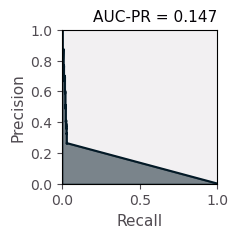

In [5]:
# plot the precision recall curve
bin_stats.plot_precision_recall_curve()

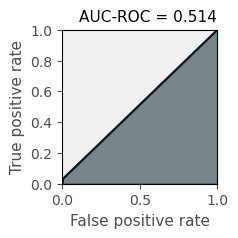

In [6]:
# plot the ROC curve
bin_stats.plot_roc_curve()

The computations and plots generated above, use the cutoff provided at the instatiation of the NetworkInferenceStats class.

If you want to change the cutoff value, you can do so by changing the cutoff attribute of the class and then calling the plot functions again.

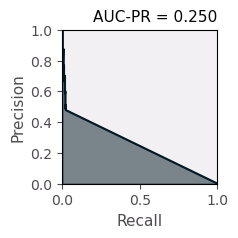

In [7]:
bin_stats.cutoff = 400
bin_stats.plot_precision_recall_curve()

You can also indicate the cutoff value when calling the method for a specific application:

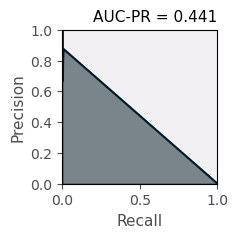

In [8]:
bin_stats.plot_precision_recall_curve(cutoff=100)

This won't change the associated cutoff value

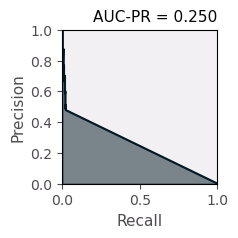

In [9]:
bin_stats.plot_precision_recall_curve()